<a href="https://colab.research.google.com/github/sarans2223/KNN/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CUSTOMER SEGMENTATION FOR A MALL USING k-NN
# ============================================================

# 1. IMPORT LIBRARIES
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# ============================================================
# 2. DOWNLOAD DATASET
# ============================================================

path = kagglehub.dataset_download(
    "vjchoudhary7/customer-segmentation-tutorial-in-python"
)

print("Dataset path:", path)

# Show files inside downloaded folder
print("Files:", os.listdir(path))

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
Dataset path: /kaggle/input/customer-segmentation-tutorial-in-python
Files: ['Mall_Customers.csv']


In [ ]:
# ============================================================
# 3. LOAD DATASET
# ============================================================

file_path = os.path.join(path, "Mall_Customers.csv")

df = pd.read_csv(file_path)

print(df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nColumns:")
print(df.columns)

print("\nDataset information:")
print(df.info())

(200, 5)

First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Columns:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-n

In [ ]:
# ============================================================
# 4. CREATE CUSTOMER CATEGORY
# ============================================================
# The original dataset does not contain a category column.
# We create categories using Spending Score.
#
# 0 - 40   -> Low
# 41 - 70  -> Medium
# 71 - 100 -> High
# ============================================================

def create_category(score):

    if score <= 40:
        return "Low"

    elif score <= 70:
        return "Medium"

    else:
        return "High"


df["Category"] = df["Spending Score (1-100)"].apply(create_category)


print("\nCustomer categories:")
print(df[[
    "Annual Income (k$)",
    "Spending Score (1-100)",
    "Category"
]].head(10))


Customer categories:
   Annual Income (k$)  Spending Score (1-100) Category
0                  15                      39      Low
1                  15                      81     High
2                  16                       6      Low
3                  16                      77     High
4                  17                      40      Low
5                  17                      76     High
6                  18                       6      Low
7                  18                      94     High
8                  19                       3      Low
9                  19                      72     High


In [ ]:
# ============================================================
# 5. CHECK CATEGORY COUNTS
# ============================================================

print("\nCategory counts:")
print(df["Category"].value_counts())


Category counts:
Category
Medium    83
Low       63
High      54
Name: count, dtype: int64


In [ ]:
# ============================================================
# 6. SELECT FEATURES AND TARGET
# ============================================================
#
# X = Annual Income + Spending Score
# y = Customer Category
# ============================================================

X = df[
    [
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]

y = df["Category"]

In [ ]:
# ============================================================
# 7. SPLIT DATA INTO TRAINING AND TESTING
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (160, 2)
Testing data: (40, 2)


In [ ]:
# ============================================================
# 8. FEATURE SCALING
# ============================================================
# k-NN uses distance, so scaling is important.
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
# ============================================================
# 9. TEST DIFFERENT k VALUES
# ============================================================

k_values = [1, 3, 5, 7, 11, 15, 21]

print("\n==============================")
print("ACCURACY FOR DIFFERENT k")
print("==============================")

for k in k_values:

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    y_pred = model.predict(
        X_test_scaled
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    print(
        "k =", k,
        "Accuracy =", round(accuracy, 4)
    )


ACCURACY FOR DIFFERENT k
k = 1 Accuracy = 1.0
k = 3 Accuracy = 1.0
k = 5 Accuracy = 1.0
k = 7 Accuracy = 1.0
k = 11 Accuracy = 0.975
k = 15 Accuracy = 0.975
k = 21 Accuracy = 0.975


In [ ]:
# ============================================================
# 10. SELECT FINAL k
# ============================================================
# We will use k = 5 for prediction.
# ============================================================

k = 5

model = KNeighborsClassifier(
    n_neighbors=k
)

model.fit(
    X_train_scaled,
    y_train
)



KNeighborsClassifier()

In [ ]:
# ============================================================
# 11. TEST SET PREDICTION
# ============================================================

y_pred = model.predict(
    X_test_scaled
)


print("\n==============================")
print("CLASSIFICATION REPORT")
print("==============================")

print(
    classification_report(
        y_test,
        y_pred
    )
)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        11
         Low       1.00      1.00      1.00        12
      Medium       1.00      1.00      1.00        17

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [ ]:
# ============================================================
# 12. PREDICT A NEW CUSTOMER
# ============================================================

print("\n==============================")
print("NEW CUSTOMER PREDICTION")
print("==============================")

income = float(
    input("Enter annual income (k$): ")
)

spending = float(
    input("Enter spending score (1-100): ")
)


# Create new customer data
new_customer = np.array([
    [income, spending]
])


# Scale new customer
new_customer_scaled = scaler.transform(
    new_customer
)


# Predict category
prediction = model.predict(
    new_customer_scaled
)


print("\nNew Customer Details")
print("--------------------")
print("Annual Income:", income, "k$")
print("Spending Score:", spending)
print("Predicted Category:", prediction[0])


NEW CUSTOMER PREDICTION
Enter annual income (k$): 15
Enter spending score (1-100): 20

New Customer Details
--------------------
Annual Income: 15.0 k$
Spending Score: 20.0
Predicted Category: Low


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# ============================================================
# 13. DECISION BOUNDARY FUNCTION
# ============================================================

def plot_decision_boundary(k):

    # Create model
    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    # Train model
    knn.fit(
        X_train_scaled,
        y_train
    )


    # Find minimum and maximum values
    x_min = X_train_scaled[:, 0].min() - 1
    x_max = X_train_scaled[:, 0].max() + 1

    y_min = X_train_scaled[:, 1].min() - 1
    y_max = X_train_scaled[:, 1].max() + 1


    # Create grid
    xx, yy = np.meshgrid(
        np.arange(
            x_min,
            x_max,
            0.02
        ),

        np.arange(
            y_min,
            y_max,
            0.02
        )
    )


    # Convert grid into rows
    grid = np.c_[
        xx.ravel(),
        yy.ravel()
    ]


    # Predict every point in grid
    predictions = knn.predict(
        grid
    )


    # Convert categories into numbers
    category_map = {
        "Low": 0,
        "Medium": 1,
        "High": 2
    }


    Z = np.array([
        category_map[p]
        for p in predictions
    ])


    Z = Z.reshape(
        xx.shape
    )


    # Plot decision boundary
    plt.figure(
        figsize=(9, 6)
    )


    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.3
    )


    # Plot Low customers
    mask_low = (
        y_train == "Low"
    )

    plt.scatter(
        X_train_scaled[mask_low, 0],
        X_train_scaled[mask_low, 1],
        label="Low"
    )


    # Plot Medium customers
    mask_medium = (
        y_train == "Medium"
    )

    plt.scatter(
        X_train_scaled[mask_medium, 0],
        X_train_scaled[mask_medium, 1],
        label="Medium"
    )


    # Plot High customers
    mask_high = (
        y_train == "High"
    )

    plt.scatter(
        X_train_scaled[mask_high, 0],
        X_train_scaled[mask_high, 1],
        label="High"
    )


    # Labels
    plt.xlabel(
        "Annual Income (Scaled)"
    )

    plt.ylabel(
        "Spending Score (Scaled)"
    )

    plt.title(
        "k-NN Decision Boundary (k = " + str(k) + ")"
    )

    plt.legend()

    plt.show()

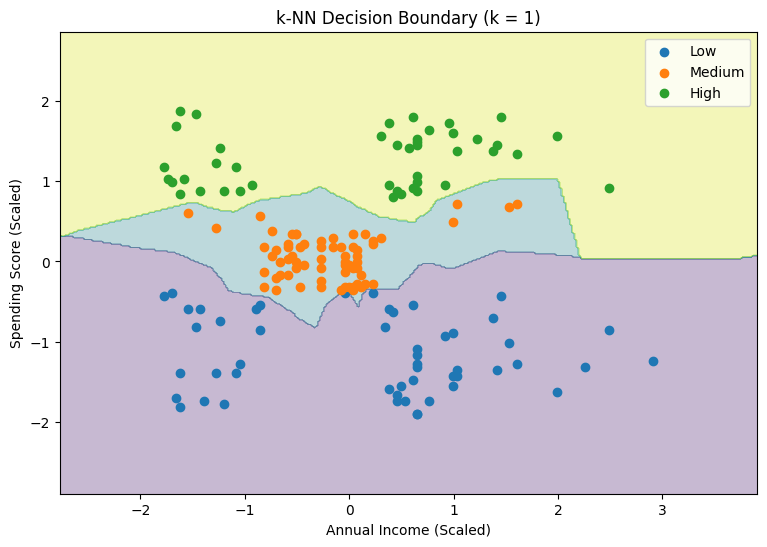

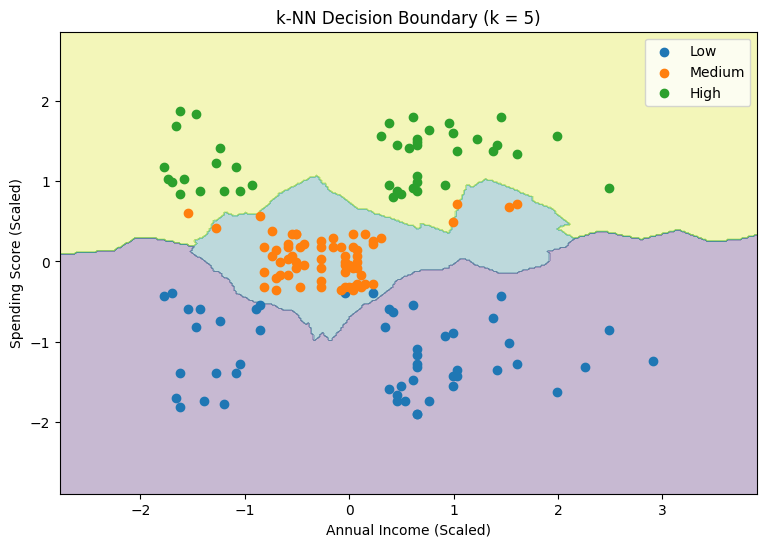

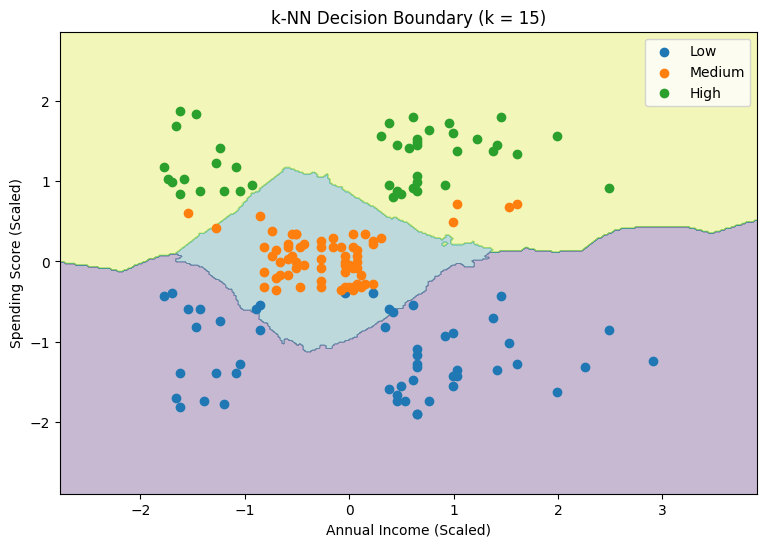

In [ ]:
# ============================================================
# 14. VISUALIZE DECISION BOUNDARIES
# ============================================================

plot_decision_boundary(1)

plot_decision_boundary(5)

plot_decision_boundary(15)